# Read Data

In [ ]:
# pip install -U transformers datasets accelerate scikit-learn pandas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

In [ ]:
from google.colab import drive
import os
import pickle
drive.mount('/content/drive', force_remount = True)
os.chdir('/content/drive/MyDrive')
df_train = pd.read_csv("train_abstracts.csv")# read data
#df_test = pd.read_csv("abstracts_physics.csv")
df_test = pd.read_csv("abstracts_ood.csv")


Mounted at /content/drive


In [ ]:
df_train = df_train[df_train.iloc[:, 2].isin(["stat.TH", "stat.AP", "stat.CO", "stat.ML"])].reset_index(drop=True)


In [ ]:
df = pd.read_csv("data_extension_abstracts.csv")

In [ ]:
df = df[df.iloc[:, 1].isin(["stat.TH", "stat.AP", "stat.CO", "stat.ML"])].reset_index(drop=True)


In [ ]:
df_train.iloc[:, 2] = df_train.iloc[:, 2].replace({
    "stat.TH": "theory",
    "stat.AP": "application",
    "stat.CO": "computation",
    "stat.ML": "machine_learning"
})

In [ ]:
df.iloc[:, 1] = df.iloc[:, 1].replace({
    "stat.TH": "theory",
    "stat.AP": "application",
    "stat.CO": "computation",
    "stat.ML": "machine_learning"
})

In [ ]:
# 2) Encode labels
le = LabelEncoder()
df_train["label"] = le.fit_transform(df_train["stat_category"])
df_test["label"] = le.transform(df_test["physics_category"])
df["label"] = le.transform(df["stat_category"])

# LDA

In [ ]:
import re
from sklearn.feature_extraction.text import CountVectorizer

# Clean text
texts = df_train["abstract"].astype(str).tolist()
def simple_clean(t):
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t
texts = [simple_clean(t) for t in texts]

# Bag-of-words (no TF-IDF for LDA)
vect = CountVectorizer(stop_words="english", min_df=5, max_df=0.9)
X = vect.fit_transform(texts)
vocab = vect.get_feature_names_out()

from sklearn.decomposition import LatentDirichletAllocation


In [ ]:



results = []
for K in np.arange(1, 15):
    lda = LatentDirichletAllocation(n_components=K, random_state=42, max_iter=40, n_jobs=-1)
    lda.fit(X)
    ll = lda.score(X)          # higher is better
    perp = lda.perplexity(X)   # lower is better
    results.append((K, ll, perp))

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
plt.plot(np.arange(1,15), [i[1] for i in results], label = "log-likelihood")
plt.legend()
plt.show()

NameError: name 'results' is not defined

In [ ]:
lda = LatentDirichletAllocation(n_components=4, random_state=42, max_iter=40, n_jobs=-1)
lda.fit(X)
all_embedding = lda.fit_transform(X)


# LAKCP

In [ ]:
!pip install ternary
from LatentKernCP.lakcp import LAKCP


  Preparing metadata (setup.py) ... done
  Created wheel for ternary: filename=ternary-0.1-py3-none-any.whl size=1751 sha256=e9f9468c08679d8b784d807e87d14b9417588d32f780934c4aed2ce0ec6ec017
  Stored in directory: /root/.cache/pip/wheels/d7/6e/54/60848f233a06e5db63831ed34cf4210628ba15030f8b6b4fa3
Successfully built ternary


In [ ]:
last_idx = df[df.iloc[:, 2] > 0].index[-1]
last_idx = int((last_idx + 1) / 3)
last_idx

81

In [ ]:
def compute_lambda(df, exception):
  lambdas = []
  for i in range( last_idx):
    sub_df = df.iloc[(3 * i):(3 * (i + 1)),: ]

    sorted_df = sub_df.sort_values("flash-score")

    lambda_val = None

    for i, candidate in enumerate(sorted_df["flash-score"]):
        # Subset where flash-score >= candidate
        subset = sub_df.loc[sub_df["flash-score"] >= candidate]

        # Count exceptions (pro-score != 1)
        exceptions = (subset["pro-score"] < .5).sum()

        if exceptions <= exception:   # allow at most three exception
            lambda_val = candidate
            if i == 0:
              lambda_val = 0
            break
    if lambda_val is None:
      lambda_val = 1
    lambdas.append(lambda_val)

  return np.array(lambdas)


In [ ]:
names = ["lambda1"]
exceptions = [0]
lambdas_ls = []
cutoffs = []
for i, name in enumerate(names):
  alpha = .05
  lambdas = compute_lambda(df, exceptions[i])
  Zcal = all_embedding[:last_idx, :]
  Ztest =  all_embedding[last_idx:, :]
  res_cal = lambdas


  print("Starting LAKCP...")
  lakcp = LAKCP(
      alpha=alpha,
      max_steps=200,
      eps=1e-03,
      tol=1e-06,
      thres=10.0,
      ridge=1e-08,
      start_side='left',
      gamma=None,
      gamma_grid=np.logspace(-1, 1, 30),
      randomize=False,
      verbose=False
  )

  # If you later add KMeans on Ztrain_pca (fit ONCE & save centroids), create one-hot Φ_cal/Φ_test.
  Phi_cal  = np.ones((Zcal.shape[0], 1))
  Phi_test = np.ones((Ztest.shape[0], 1))

  cutoffs_lakcp = lakcp.fit(Zcal, Phi_cal, res_cal.ravel(),
                            Ztest, Phi_test)

  # === LAKCP (CV) ====
  print("Starting LAKCP with CV...")
  lakcp_cv = LAKCP(
      alpha=alpha,
      max_steps=200,
      eps=1e-03,
      tol=1e-06,
      thres=10.0,
      ridge=1e-08,
      start_side='left',
      gamma=None,
      gamma_grid=np.logspace(-1, 1, 30),
      use_cv=True,
      randomize=True,
      verbose=False
  )
  cutoffs_lakcp_cv = lakcp_cv.fit(Zcal, Phi_cal, res_cal.ravel(),
                            Ztest, Phi_test)
  cutoffs.append(cutoffs_lakcp_cv[0])
  lambdas_ls.append(lambdas)


Starting LAKCP...
Starting LAKCP with CV...


In [ ]:
df["lambda1"] = 0

for i in range(last_idx):
  df.iloc[ (i * 3): ((i + 1) * 3) , 5] = lambdas_ls[0][i]

for i in range(last_idx, 325):
  df.iloc[ (i * 3): ((i + 1) * 3) , 5] = cutoffs[0][i- 100]


/tmp/ipython-input-2419545076.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[ (i * 3): ((i + 1) * 3) , 5] = lambdas_ls[0][i]


# Performance

In [ ]:
# Small LM fine-tune with LoRA (PEFT) — drop-in for your DatasetDict
# pip install transformers peft accelerate datasets bitsandbytes (if GPU + 4bit)

import numpy as np
from datasets import DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

def train_and_eval_small_lm_lora(
    dataset: DatasetDict,
    model_name: str = "distilbert-base-uncased",
    run_name: str = "small_lm_lora",
    max_length: int = 192,
    lora_r: int = 8,
    lora_alpha: int = 16,
    lora_dropout: float = 0.1,
    lr: float = 2e-4,
    batch_size: int = 32,
    num_epochs: int = 20,
):
    # infer num labels
    labels = list(set(dataset["train"]["label"]))
    label2id = {y:i for i,y in enumerate(sorted(labels))}
    id2label = {i:y for y,i in label2id.items()}

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    def preprocess(batch):
        y = [label2id[v] for v in batch["label"]]
        x = tokenizer(batch["abstract"], truncation=True, max_length=max_length)
        x["labels"] = y
        return x

    ds_proc = DatasetDict({
        split: ds.map(preprocess, batched=True, remove_columns=ds.column_names)
        for split, ds in dataset.items()
    })

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    # Set up LoRA on attention projections (common, lightweight)
    peft_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=["q_lin","k_lin","v_lin","out_lin","query","key","value","dense"]  # robust across archs
    )
    model = get_peft_model(base_model, peft_cfg)

    # Training args with early stopping on your validation split
    args = TrainingArguments(
        output_dir=f"./runs/{run_name}",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),  # use fp16 if possible
        seed=42,
        disable_tqdm=True, # Add this line
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_proc["train"],
        eval_dataset=ds_proc["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # Evaluate
    test_metrics = trainer.evaluate(ds_proc["test"])

    outdir = f"./runs/{run_name}"
    if os.path.exists(outdir):
        shutil.rmtree(outdir)  # removes the whole folder with checkpoints
        print(f"Deleted {outdir}")

    return {
        "test": {k: float(v) for k, v in test_metrics.items() if k.startswith("eval_")},
        "run_name": run_name,
        "model_name": model_name,
        "trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

In [ ]:
import numpy as np
import pandas as pd
import shutil


final_res = []
for iii in range(20):
  np.random.seed( iii + 1)

  first_100 = np.arange(last_idx)

  random_400 = np.random.choice(
      np.arange(last_idx, df_train.shape[0]),
      size=150,
      replace=False
  )

  selected_index = np.concatenate([first_100, random_400])
  print(sum(selected_index))
  df1 = df_train.iloc[selected_index, :][["abstract", "label"]]

  # Create validation set from unused indices
  val_indices = np.setdiff1d(np.arange(df_train.shape[0]), selected_index)
  df_val = df_train.iloc[val_indices, :]

  selected_index2 = np.concatenate([np.arange(3 * j, 3 * (j + 1)) for j in selected_index])
  df_sub = df.iloc[selected_index2, :]


  df2 = df_sub[["abstract", "label"]]


  df3 = df_sub.loc[df_sub["flash-score"] >= 0.5, ["abstract", "label"]]

  df4 = df_sub.loc[ (df_sub["pro-score"] >= 0.5) | ((df_sub["pro-score"] == -1) & (df_sub["flash-score"] >= 0.5)), ["abstract", "label"]
  ]

  df5 = df_sub.loc[
      (df_sub["pro-score"] >= .5) |
      ((df_sub["pro-score"] == -1) & (df_sub["flash-score"] >= df_sub["lambda1"])),
      ["abstract", "label"]
  ]


  dfs = [df1, df2, df3, df4, df5]
  print(df1.shape)
  print(df2.shape)
  print(df3.shape)
  print(df4.shape)
  print(df5.shape)
  datasets = []

  for i, dff in enumerate(dfs):

    if i == 0:
      cur_df = dff
    else:
      cur_df = pd.concat((df1, dff), axis = 0, ignore_index = True)
    datasets.append(DatasetDict({
        "train": Dataset.from_pandas(cur_df[["abstract", "label"]].reset_index(drop=True)),
        "validation": Dataset.from_pandas(df_val[["abstract", "label"]].reset_index(drop=True)),
        "test": Dataset.from_pandas(df_test[["abstract", "label"]].reset_index(drop=True)),
    }))


  all_results = []
  for i, ds in enumerate(datasets):
      res = train_and_eval_small_lm_lora(ds, run_name=f"tfidf_logreg_run_{i}")
      all_results.append(res["test"])
      print(iii, i)
      print(res["test"])
  final_res.append(all_results)

58145
(231, 2)
(693, 2)
(644, 2)
(656, 2)
(627, 2)


Map:   0%|          | 0/231 [00:00<?, ? examples/s]

Map:   0%|          | 0/413 [00:00<?, ? examples/s]

Map:   0%|          | 0/164 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3324377882.py:90: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map:   0%|          | 0/838 [00:00<?, ? examples/s]

Map:   0%|          | 0/413 [00:00<?, ? examples/s]

Map:   0%|          | 0/164 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3324377882.py:90: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'eval_loss': 1.1713441610336304, 'eval_accuracy': 0.5375302663438256, 'eval_precision': 0.4090356426879117, 'eval_recall': 0.5375302663438256, 'eval_f1': 0.45804618669802055, 'eval_runtime': 0.7025, 'eval_samples_per_second': 587.896, 'eval_steps_per_second': 18.505, 'epoch': 1.0}
{'loss': 1.2222, 'grad_norm': 2.0177221298217773, 'learning_rate': 0.00018185185185185185, 'epoch': 1.8518518518518519}
{'eval_loss': 0.9975320100784302, 'eval_accuracy': 0.6101694915254238, 'eval_precision': 0.649335203936809, 'eval_recall': 0.6101694915254238, 'eval_f1': 0.5992251329323363, 'eval_runtime': 0.7059, 'eval_samples_per_second': 585.033, 'eval_steps_per_second': 18.415, 'epoch': 2.0}
{'eval_loss': 0.9268181324005127, 'eval_accuracy': 0.6537530266343826, 'eval_precision': 0.6771152806207718, 'eval_recall': 0.6537530266343826, 'eval_f1': 0.6455712566512203, 'eval_runtime': 0.7081, 'eval_samples_per_second': 583.213, 'eval_steps_per_second': 18.358, 'epoch': 3.0}
{'loss': 0.932, 'grad_norm': 3.464

In [ ]:
#with open("final_res_20_abstracts_physics.pkl", "wb") as f:
#with open("final_res_20_abstracts_physics_3.pkl", "wb") as f:
with open("final_res_20_abstracts_ood_3.pkl", "wb") as f:
    pickle.dump(final_res, f)


In [ ]:

with open("final_res_20_abstracts_ood_3.pkl", "rb") as f:
    final_res = pickle.load(f)


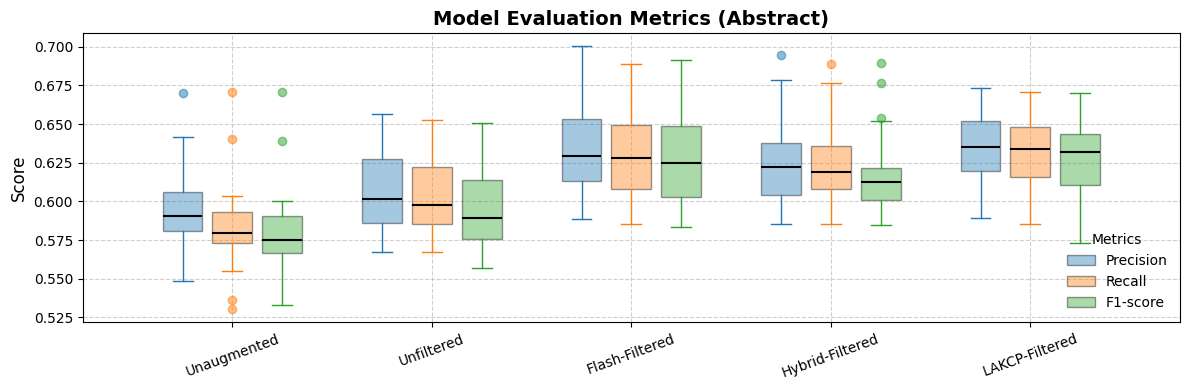

In [ ]:
labels = ["original", "unfilterd", "flash", "1/3pro+2/3flash", "LAKCP"]
res1 = np.array([ [ j["eval_precision"] for j in i ] for i in final_res])
res2 = np.array([ [ j["eval_accuracy"] for j in i ] for i in final_res])
res3 = np.array([ [ j["eval_recall"] for j in i ] for i in final_res])
res4 = np.array([ [ j["eval_f1"] for j in i ] for i in final_res])
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Example labels
labels = ["Unaugmented", "Unfiltered", "Flash-Filtered", "Hybrid-Filtered", "LAKCP-Filtered"]

# Results arrays (shape: n_runs × n_labels)
metrics = {
    "Precision": res1,
    "Recall": res3,
    "F1-score": res4
}

colors = plt.cm.tab10.colors
plt.figure(figsize=(12, 4))

# X positions for each method
x = np.arange(len(labels))
width = 0.25  # box width

for i, (metric_name, res) in enumerate(metrics.items()):
    # Compute offset for dodging
    positions = x + (i - 1) * width

    # Build boxplot values column-wise
    data = [res[:, j] for j in range(res.shape[1])]

    plt.boxplot(
        data,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], alpha=0.4),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color=colors[i]),
        capprops=dict(color=colors[i]),
        flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], alpha=0.5)
    )

# Style
plt.xticks(x, labels, rotation=20)
plt.ylabel("Score", fontsize=12)
plt.title("Model Evaluation Metrics (Abstract)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.6, linestyle="--")

# Legend in bottom right
legend_elements = [Patch(facecolor=colors[i], edgecolor="black", alpha=0.4, label=metric_name)
                   for i, metric_name in enumerate(metrics.keys())]
plt.legend(handles=legend_elements, title="Metrics", frameon=False, loc="lower right")

plt.tight_layout()
plt.show()
